# Classical Machine Learning Models: Decision Tree, Random Forest, Naive Bayes

Input: feature engineered data `data/processed/features_train.csv` and `data/processed/features_test.csv`


Loads `data/processed/features_train.csv` / `features_test.csv` from
`02_eda_feature_selection.ipynb` and trains the three required classical models. Each model's
test-set metrics are appended to `outputs/results/model_metrics.json`, which
`05_model_comparison.ipynb` reads to build the final four-model comparison — so this notebook
can be re-run on its own at any time without disturbing the ANN's results.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from helpers.nb_utils import evaluate_classifier, plot_confusion, save_metrics, PROC_DIR, FIG_DIR

pd.set_option("display.max_columns", 50)

## 1. Load features and split predictors from identifiers

`country`, `cca3` and `reference_year` are kept alongside the model but not fed to it as
predictors — `cca3` in particular is needed in the next step, to group rows by country during
cross-validation.

In [2]:
train = pd.read_csv(PROC_DIR / "features_train.csv")
test = pd.read_csv(PROC_DIR / "features_test.csv")

ID_COLS = ["country", "cca3", "reference_year"]
TARGET = "target_exposure_class"
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET]]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]
groups_train = train["cca3"]

print(f"{len(FEATURE_COLS)} predictors: {FEATURE_COLS}")
print(f"Training rows: {len(X_train)} across {groups_train.nunique()} countries")

15 predictors: ['population_at_reference', 'density_at_reference', 'population_growth_prior_decade_pct', 'prior_decade_mean_temp_c', 'prior_decade_warming_c_per_decade', 'prior_decade_volatility_c', 'prior_decade_uncertainty_c', 'area_km2', 'population_growth_is_estimated', 'continent_Africa', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America']
Training rows: 663 across 221 countries


## 2. Why cross-validation is grouped by country, not random

Each country contributes three rows to training (1970, 1980, 1990), and those three rows share
almost everything about that country except the decade — they are not independent samples. A
plain random K-fold split could put, say, France-1970 in a training fold and France-1980 in the
validation fold, letting a model tune itself against a country it has effectively already seen a
near-duplicate of. `GroupKFold`, grouped by `cca3`, keeps every row for a given country in the
same fold, so validation performance during tuning isn't inflated by this kind of near-leakage.

In [3]:
cv = GroupKFold(n_splits=5)

## 3. Decision Tree

A single decision tree is prone to overfitting on a training set this size if left unconstrained
(it can happily carve out a leaf for every training row). `max_depth` and `min_samples_leaf` are
tuned specifically to control that, using grouped cross-validation and macro-F1 as the scoring
metric — macro-F1 rather than accuracy, so the search doesn't implicitly favour whichever class
happens to be easiest, given the test set's imbalance noted earlier.

Best Decision Tree params: {'max_depth': 8, 'min_samples_leaf': 5}
Best cross-validated macro-F1: 0.615
=== Decision Tree ===
              precision    recall  f1-score   support

         Low       0.57      0.47      0.51        62
      Medium       0.42      0.43      0.42        93
        High       0.38      0.42      0.40        66

    accuracy                           0.44       221
   macro avg       0.45      0.44      0.45       221
weighted avg       0.45      0.44      0.44       221

Saved metrics for 'Decision Tree' to /home/claude/project/outputs/results/model_metrics.json


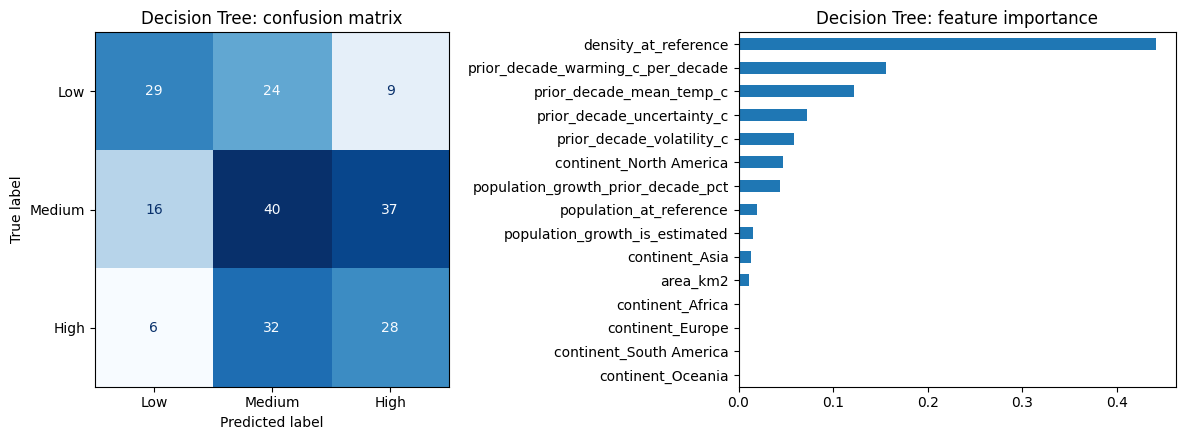

In [4]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 5, 10, 20],
    },
    scoring="f1_macro",
    cv=cv.split(X_train, y_train, groups=groups_train),
    n_jobs=-1,
)
dt_grid.fit(X_train, y_train)
print("Best Decision Tree params:", dt_grid.best_params_)
print(f"Best cross-validated macro-F1: {dt_grid.best_score_:.3f}")

dt_model = dt_grid.best_estimator_
dt_pred = dt_model.predict(X_test)
dt_metrics = evaluate_classifier("Decision Tree", y_test, dt_pred)
save_metrics(dt_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(y_test, dt_pred, title="Decision Tree: confusion matrix", ax=axes[0])
pd.Series(dt_model.feature_importances_, index=FEATURE_COLS).sort_values().plot(
    kind="barh", ax=axes[1], title="Decision Tree: feature importance"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_decision_tree.png", dpi=200)
plt.show()

## 4. Random Forest

Averaging many trees, each trained on a bootstrap resample with a random subset of features at
each split, reduces the variance that a single small tree is prone to. `n_estimators` and
`max_depth` are tuned the same grouped way as the Decision Tree, for a fair comparison between
the two.

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best cross-validated macro-F1: 0.658
=== Random Forest ===
              precision    recall  f1-score   support

         Low       0.53      0.42      0.47        62
      Medium       0.39      0.30      0.34        93
        High       0.39      0.59      0.47        66

    accuracy                           0.42       221
   macro avg       0.44      0.44      0.43       221
weighted avg       0.43      0.42      0.41       221

Saved metrics for 'Random Forest' to /home/claude/project/outputs/results/model_metrics.json


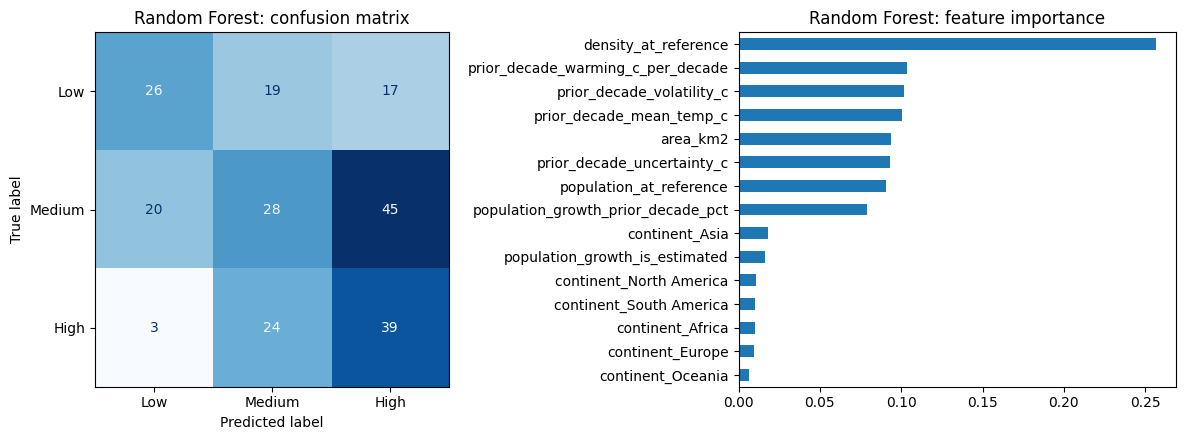

In [5]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 300, 500],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 5, 10],
    },
    scoring="f1_macro",
    cv=cv.split(X_train, y_train, groups=groups_train),
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("Best Random Forest params:", rf_grid.best_params_)
print(f"Best cross-validated macro-F1: {rf_grid.best_score_:.3f}")

rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)
rf_metrics = evaluate_classifier("Random Forest", y_test, rf_pred)
save_metrics(rf_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(y_test, rf_pred, title="Random Forest: confusion matrix", ax=axes[0])
pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values().plot(
    kind="barh", ax=axes[1], title="Random Forest: feature importance"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_random_forest.png", dpi=200)
plt.show()

## 5. Naive Bayes

`GaussianNB` assumes every feature is normally distributed *within each class* and independent
of every other feature given the class. Neither assumption is exactly true here — the one-hot
continent columns are 0/1 indicators, not continuous, and Section 6 of the previous notebook
found a real −0.7 correlation between mean temperature and temperature volatility. This is a
known, common simplification for applying Gaussian Naive Bayes to mixed feature types, not an
oversight, and it's exactly why we expect (and should openly report) Naive Bayes performing
differently from the tree-based models, rather than tuning it to try to hide that.

There's no meaningful hyperparameter search for `GaussianNB` beyond its variance-smoothing term,
so it's fit directly on the training data.

=== Naive Bayes ===
              precision    recall  f1-score   support

         Low       0.60      0.29      0.39        62
      Medium       0.67      0.02      0.04        93
        High       0.35      1.00      0.52        66

    accuracy                           0.39       221
   macro avg       0.54      0.44      0.32       221
weighted avg       0.55      0.39      0.28       221

Saved metrics for 'Naive Bayes' to /home/claude/project/outputs/results/model_metrics.json


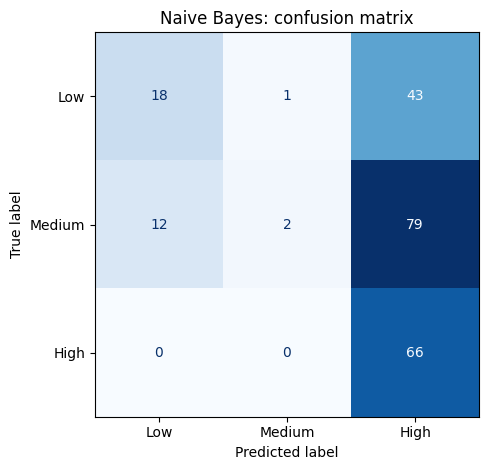

In [6]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_metrics = evaluate_classifier("Naive Bayes", y_test, nb_pred)
save_metrics(nb_metrics)

plot_confusion(y_test, nb_pred, title="Naive Bayes: confusion matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_naive_bayes.png", dpi=200)
plt.show()

## 6. Classical models, side by side

A quick comparison of just these three before bringing the ANN into it in the next notebook —
useful on its own for the "Algorithm and Model Overview" section, and a sanity check that
nothing regressed before moving on.

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Decision Tree,0.439,0.455,0.441,0.446,0.448,0.439,0.442
Random Forest,0.421,0.437,0.437,0.426,0.430,0.421,0.415
Naive Bayes,0.389,0.539,0.437,0.318,0.554,0.389,0.283


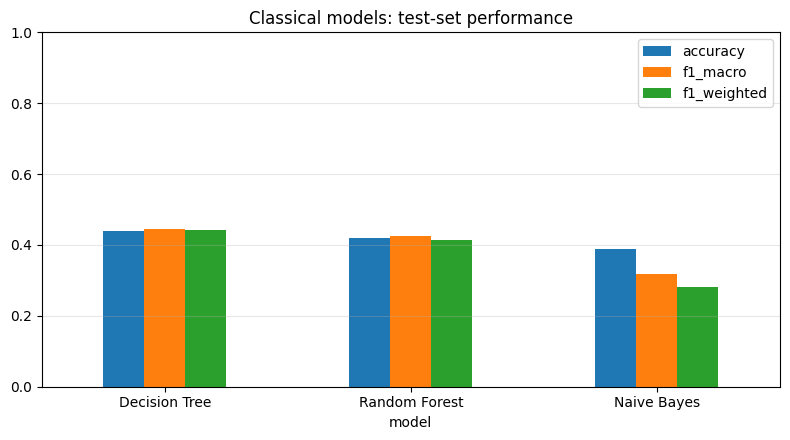

In [7]:
classical_results = pd.DataFrame([dt_metrics, rf_metrics, nb_metrics]).set_index("model")
display(classical_results.round(3))

classical_results[["accuracy", "f1_macro", "f1_weighted"]].plot(kind="bar", rot=0, figsize=(8, 4.5))
plt.title("Classical models: test-set performance")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_classical_comparison.png", dpi=200)
plt.show()

**Reading these results honestly:** accuracy sits around 0.39–0.44 for all three models —
clearly better than the 0.33 random-guess baseline for three balanced-ish classes, but modest.
That's an expected consequence of the dataset's real constraint, not a bug to chase away: the
model only ever sees 221 independent countries (each repeated 3 times across decades, not 663
independent observations — see the cross-validation note above), and it's asked to generalise
from the 1970s–1990s to a held-out decade it has never seen. Naive Bayes' near-zero recall on the
"Medium" class specifically is also a genuine, explainable pattern worth reporting rather than
hiding: its independence assumption blurs the decision boundary hardest in the middle of a
three-way split, where the margin between classes is thinnest. This is a legitimate,
presentable finding about *why* a simpler model struggles here — not a mistake to fix by quietly
re-running until the number looks better.

## Where this leaves you

- All three classical models' metrics are saved to `outputs/results/model_metrics.json`.
- `04_deep_learning_ann.ipynb` reads the same `features_train.csv` / `features_test.csv`, so its
  results append to the same file rather than needing to be manually merged.
- The feature importance plots above and the mutual-information ranking from the previous
  notebook should tell a consistent story — if a feature ranks highly in one and not the other,
  that's worth a sentence in the report, not something to quietly ignore.